## Projeto Prático 3: Segmentação Semântica com U-Net

A subseção de Segmentação Semântica apresentou um modelo pré-treinado (DeepLabV3) produzindo diretamente um rótulo de classe por pixel, sem qualquer etapa de treinamento. Esta seção completa a sequência de projetos práticos do capítulo — classificação (Projeto Prático 1) e detecção (Projeto Prático 2) — com a terceira tarefa fundamental descrita na @tbl-panorama-tarefas: a segmentação semântica, agora implementada e treinada do zero com a **U-Net**, arquitetura de referência para essa tarefa, introduzida originalmente para imagens biomédicas por Ronneberger, Fischer e Brox (2015).

A diferença estrutural em relação à CNN de classificação do Projeto Prático 1 é decisiva. Naquela rede, o mapa de características final era achatado (*flatten*) em um vetor, descartando toda a informação espacial em favor de um único rótulo por imagem. Uma U-Net, ao contrário, precisa produzir uma saída com a mesma resolução espacial da entrada: um mapa em que cada pixel recebe sua própria classificação. Essa exigência — preservar detalhe espacial de alta resolução até a última camada, ao mesmo tempo em que se constrói contexto semântico mais amplo em camadas intermediárias — motiva a arquitetura de codificador-decodificador (*encoder-decoder*) apresentada adiante.

O cenário utilizado nesta seção adapta um problema de segmentação de nódulos em mamografias sintéticas: imagens em tons de cinza contêm uma região circular (o "nódulo") sobreposta a um fundo, ambos contaminados pelo mesmo ruído gaussiano e com médias de intensidade próximas — um cenário deliberadamente pouco discriminável pixel a pixel, projetado para tornar visível o ganho trazido pelo aprendizado de características espaciais, e não apenas locais.

In [5]:
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import skimage.data as skdata
from morph import mm  # biblioteca didática de visão computacional

### Um Conjunto Sintético de Imagens com Nódulos

O gerador a seguir produz pares (imagem, máscara): a imagem contém uma região circular de intensidade média ligeiramente mais alta que o fundo, ambas as regiões contaminadas por ruído gaussiano de mesmo desvio-padrão — de modo que a distinção entre nódulo e fundo não é confiável pixel a pixel isoladamente, apenas quando se considera a vizinhança espacial em conjunto. A máscara binária correspondente delimita exatamente a região do nódulo e serve como alvo (*target*) de treinamento.

In [2]:
TAM_IMG = 64

def gera_imagem_com_nodulo(tam=TAM_IMG, raio_min=7, raio_max=15, media_fundo=95,
                            media_nodulo=118, sigma_ruido=26, rng=None):
    # Fundo e nódulo compartilham o mesmo ruído gaussiano; apenas a média de
    # intensidade difere, e por pouco -- um cenário de baixo contraste,
    # propositalmente difícil para um método de limiarização simples.
    rng = rng or np.random.default_rng()
    fundo = rng.normal(media_fundo, sigma_ruido, (tam, tam))
    nodulo = rng.normal(media_nodulo, sigma_ruido, (tam, tam))
    mascara = np.zeros((tam, tam), dtype=np.uint8)
    raio = int(rng.integers(raio_min, raio_max))
    cx = int(rng.integers(raio + 4, tam - raio - 4))
    cy = int(rng.integers(raio + 4, tam - raio - 4))
    cv2.circle(mascara, (cx, cy), raio, 255, -1)
    imagem = np.clip(np.where(mascara > 0, nodulo, fundo), 0, 255).astype(np.uint8)
    return imagem, mascara

Com a função de geração definida, constrói-se o conjunto de treino, com 160 pares, e o conjunto de validação, com 40 pares, ambos amostrados da mesma distribuição estatística — condição que garante que a comparação entre métodos, adiante, reflita a dificuldade da tarefa, e não uma diferença artificial entre os dois conjuntos.

In [3]:
rng_dados = np.random.default_rng(42)
N_TREINO, N_VAL = 160, 40
imgs_treino, masks_treino = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_TREINO)])
imgs_val, masks_val = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_VAL)])

print(f"Conjunto de treino: {N_TREINO} imagens | Conjunto de validação: {N_VAL} imagens")

Conjunto de treino: 160 imagens | Conjunto de validação: 40 imagens


A @fig-09-unet-dataset exibe duas amostras do conjunto de treino, evidenciando a proximidade visual entre o nódulo e o fundo.

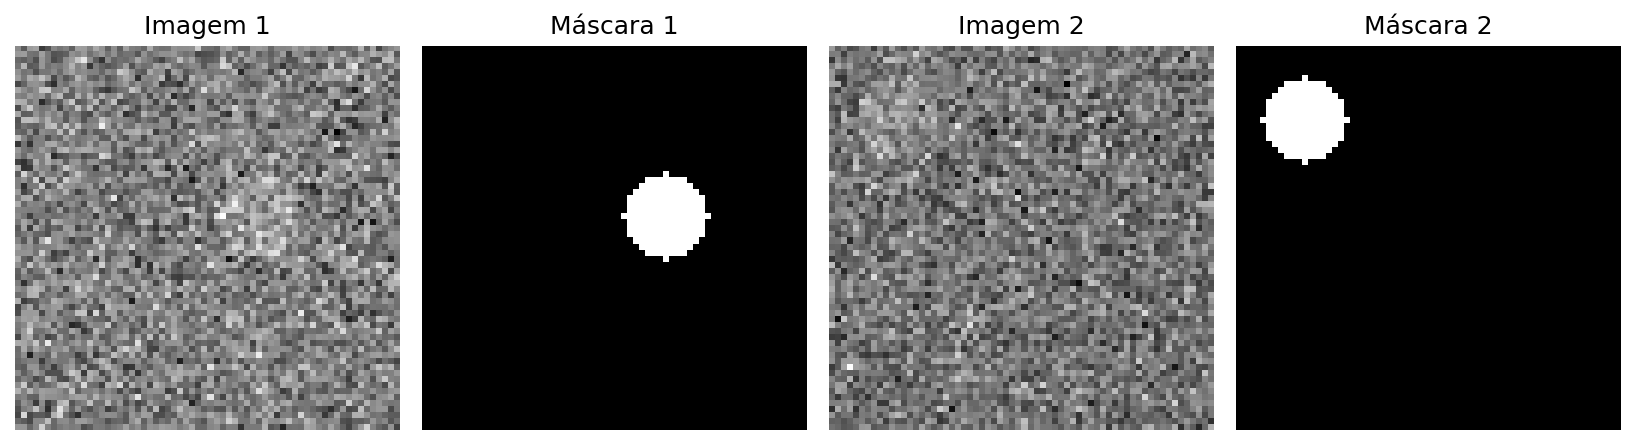

In [6]:
# @fig-09-unet-dataset
mm.show(
    [imgs_treino[0], masks_treino[0], imgs_treino[1], masks_treino[1]],
    titles=["Imagem 1", "Máscara 1", "Imagem 2", "Máscara 2"],
    cols=4, figsize=(11, 3)
)

### Linha de Base Clássica: Limiarização com *Kernel* Fixo

Antes de recorrer ao aprendizado, cabe perguntar se um *pipeline* inteiramente clássico — construído com a biblioteca `morph`, como nos capítulos anteriores — já resolve a tarefa. A abordagem mais direta combina um borrão gaussiano (*kernel* fixo, no espírito do Capítulo 3) para estimar a intensidade local, uma limiarização de Otsu (Otsu, 1979) sobre essa estimativa e uma abertura morfológica para remover ruído residual isolado.

A avaliação quantitativa dessa linha de base requer uma métrica de sobreposição entre a máscara predita e a máscara de referência. Emprega-se a Interseção sobre União (*Intersection over Union*, IoU): a razão entre a área de sobreposição das duas máscaras e a área total ocupada por ambas — métrica padrão para a comparação de segmentações (Everingham et al., 2010), já introduzida no Projeto Prático 2 para a avaliação de caixas delimitadoras e aplicável, sem modificação, a máscaras pixel a pixel.

In [7]:
def iou_mascaras(predita, referencia):
    # Interseção sobre união entre duas máscaras binárias, pixel a pixel.
    p, r = predita > 0, referencia > 0
    intersecao = np.logical_and(p, r).sum()
    uniao = np.logical_or(p, r).sum()
    return intersecao / uniao if uniao else 1.0

def segmenta_classico(imagem, elemento_estrutural):
    suavizada = mm.blur(imagem, 7)
    binaria = mm.threshold(suavizada)
    return mm.open(binaria, elemento_estrutural)

Aplicada à totalidade do conjunto de validação, essa linha de base fornece o IoU médio de referência contra o qual a U-Net será comparada adiante.

In [8]:
elemento_estrutural = mm.sedisk(5)
ious_classico = [
    iou_mascaras(segmenta_classico(img, elemento_estrutural), mask)
    for img, mask in zip(imgs_val, masks_val)
]
iou_classico_medio = float(np.mean(ious_classico))
print(f"IoU médio (linha de base clássica) no conjunto de validação: {iou_classico_medio:.4f}")

IoU médio (linha de base clássica) no conjunto de validação: 0.7516


A @fig-09-unet-classico ilustra o resultado sobre uma amostra de validação: a limiarização de Otsu tende a errar precisamente nas bordas do nódulo, região em que a diferença de intensidade em relação ao fundo é mascarada pelo ruído.

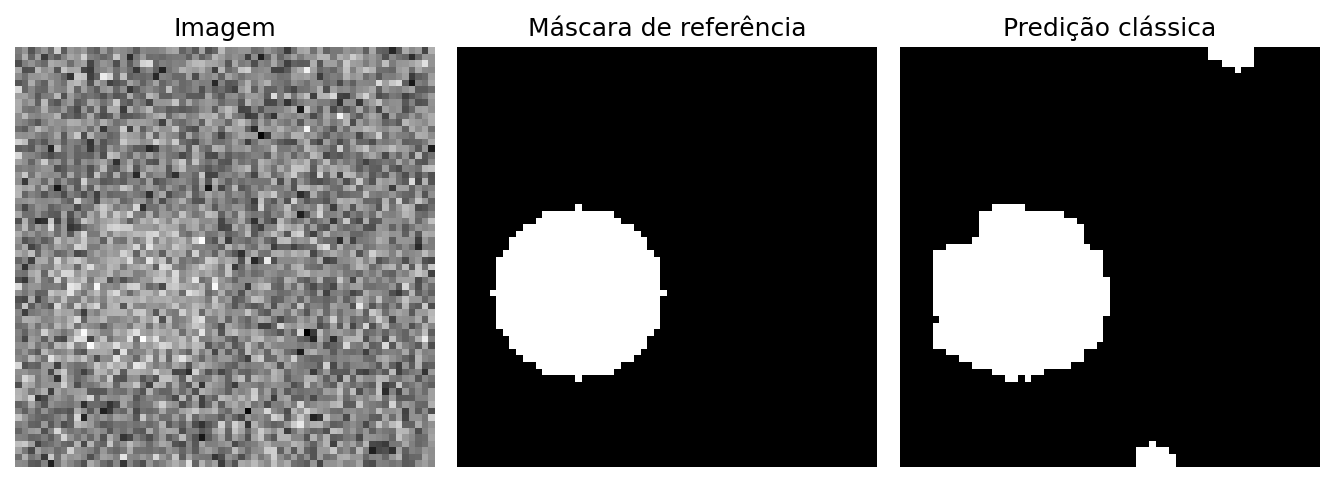

In [9]:
# @fig-09-unet-classico
predicao_classica_exemplo = segmenta_classico(imgs_val[0], elemento_estrutural)
mm.show(
    [imgs_val[0], masks_val[0], predicao_classica_exemplo],
    titles=["Imagem", "Máscara de referência", "Predição clássica"],
    cols=3, figsize=(9, 3.2)
)

### Arquitetura U-Net: Codificador-Decodificador com Conexões de Atalho

O codificador (*encoder*) repete a mesma lógica de convolução seguida de agrupamento (*pooling*) já vista no Projeto Prático 1: cada estágio reduz a resolução espacial pela metade e dobra o número de canais, construindo progressivamente características mais abstratas. Na U-Net, porém, esse processo é espelhado por um decodificador (*decoder*) simétrico, que reconstrói a resolução original por meio de convoluções transpostas — uma operação de reamostragem ascendente (*upsampling*) cujos parâmetros são aprendidos durante o treinamento, em vez de fixados por interpolação.

A diferença essencial em relação a um simples codificador-decodificador está nas conexões de atalho (*skip connections*): em cada estágio do decodificador, o mapa de características do codificador na mesma resolução — capturado antes do agrupamento correspondente — é concatenado ao resultado da reamostragem ascendente. Isso reinjeta diretamente o detalhe espacial de fronteiras e contornos, que seria perdido pelas sucessivas reduções de resolução, permitindo que a rede combine o contexto semântico amplo construído na base ("existe um nódulo nesta região?") com a precisão espacial fina das camadas iniciais ("exatamente onde está sua borda?").

```
Entrada → Codificador (Conv→Conv→Pool) × 3 → Base
                ↳ conexões de atalho reinjetam cada mapa do codificador
                  no estágio de mesma resolução do decodificador ↲
Base → Decodificador (Upsample→Concat→Conv→Conv) × 3 → Saída 1×1 (máscara)
```

A implementação a seguir é dividida em quatro partes: o bloco convolucional básico, repetido em cada estágio; a classe completa da U-Net compacta; as funções de conversão de dados e de perda; e, por fim, o laço de treinamento.

In [10]:
class BlocoConv(nn.Module):
    # Duas convoluções 3x3 + ReLU -- bloco básico repetido em cada estágio da U-Net.
    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.rede(x)

Definido o bloco convolucional, a classe `UNetCompacta` o combina em três estágios de codificação, uma base e três estágios de decodificação simétricos, com as conexões de atalho explicitadas nos comandos `torch.cat`. Trata-se de uma versão reduzida da arquitetura original (profundidade 3, poucos canais), suficiente para treinar em menos de um minuto em CPU, preservando a estrutura completa de codificador, base e decodificador.

In [11]:
class UNetCompacta(nn.Module):
    def __init__(self, canais_entrada=1, base=8):
        super().__init__()
        self.enc1 = BlocoConv(canais_entrada, base)
        self.enc2 = BlocoConv(base, base * 2)
        self.enc3 = BlocoConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.fundo = BlocoConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = BlocoConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = BlocoConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = BlocoConv(base * 2, base)

        self.saida = nn.Conv2d(base, 1, kernel_size=1)  # 1 canal: logit de "nódulo"

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        f = self.fundo(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(f), e3], dim=1))    # conexão de atalho com e3
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))   # conexão de atalho com e2
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))   # conexão de atalho com e1
        return self.saida(d1)  # logits; sigmoid aplicado na perda e na predição

A conversão dos pares (imagem, máscara) em tensores é feita por `para_tensores`. A função de perda combina duas parcelas: a entropia cruzada binária, calculada pixel a pixel entre o logit predito e o rótulo de referência, e a perda de Dice (`perda_dice`) — definida como um menos o coeficiente de Dice, a mesma medida de sobreposição empregada na arquitetura U-Net original e útil, sobretudo, quando a região de interesse ocupa uma fração pequena da imagem, caso do nódulo em relação ao fundo (Milletari, Navab & Ahmadi, 2016).

In [12]:
def para_tensores(imagens, mascaras):
    X = torch.tensor(np.stack(imagens), dtype=torch.float32).unsqueeze(1) / 255.0
    Y = torch.tensor(np.stack(mascaras), dtype=torch.float32).unsqueeze(1) / 255.0
    return X, Y

def perda_dice(logits, alvo, eps=1e-6):
    # 1 - coeficiente de Dice, a mesma métrica de sobreposição empregada na U-Net original.
    probs = torch.sigmoid(logits)
    intersecao = (probs * alvo).sum(dim=(1, 2, 3))
    uniao = probs.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + eps) / (uniao + eps)
    return 1 - dice.mean()

def perda_segmentacao(logits, alvo):
    return nn.functional.binary_cross_entropy_with_logits(logits, alvo) + perda_dice(logits, alvo)

Instanciado o modelo, o número de parâmetros treináveis confirma o caráter compacto da rede em relação a implementações completas da U-Net, que somam tipicamente alguns milhões de parâmetros.

In [13]:
modelo_unet = UNetCompacta()
print(f"Parâmetros treináveis da U-Net compacta: {sum(p.numel() for p in modelo_unet.parameters())}")

X_treino_unet, Y_treino_unet = para_tensores(imgs_treino, masks_treino)
X_val_unet, Y_val_unet = para_tensores(imgs_val, masks_val)

Parâmetros treináveis da U-Net compacta: 120681


Convertidos os dados em tensores, procede-se ao laço de treinamento propriamente dito, que otimiza os pesos da rede ao longo de 35 épocas por meio do otimizador Adam (Kingma & Ba, 2015), registrando a cada época a perda de treinamento e o IoU médio sobre o conjunto de validação.

In [14]:
otimizador_unet = optim.Adam(modelo_unet.parameters(), lr=1e-3)
n = X_treino_unet.size(0)
tam_lote = 16
epocas_unet = 35
historico_perda_unet, historico_iou_unet = [], []

for epoca in range(epocas_unet):
    modelo_unet.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0
    for i in range(0, n, tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_unet.zero_grad()
        logits = modelo_unet(X_treino_unet[idx])
        perda = perda_segmentacao(logits, Y_treino_unet[idx])
        perda.backward()
        otimizador_unet.step()
        perda_epoca += perda.item() * len(idx)

    modelo_unet.eval()
    with torch.no_grad():
        predicao_val = (torch.sigmoid(modelo_unet(X_val_unet)) > 0.5).float()
        intersecao = (predicao_val * Y_val_unet).sum(dim=(1, 2, 3))
        uniao = ((predicao_val + Y_val_unet) > 0).float().sum(dim=(1, 2, 3))
        iou_epoca = (intersecao / uniao.clamp(min=1e-6)).mean().item()
    historico_perda_unet.append(perda_epoca / n)
    historico_iou_unet.append(iou_epoca)

iou_unet_final = historico_iou_unet[-1]
print(f"IoU médio da U-Net no conjunto de validação: {iou_unet_final:.4f}")

IoU médio da U-Net no conjunto de validação: 0.8872


A @fig-09-unet-treinamento acompanha, ao longo das épocas, a queda da perda de treinamento e a evolução correspondente do IoU médio de validação.

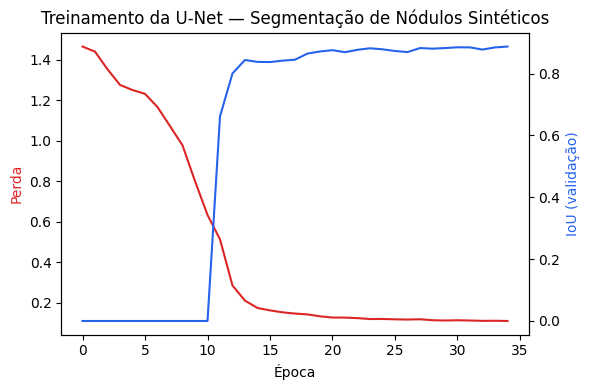

In [15]:
# @fig-09-unet-treinamento
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(historico_perda_unet, color="#dc2626", label="Perda (treino)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda", color="#dc2626")
ax2 = ax1.twinx()
ax2.plot(historico_iou_unet, color="#2563eb", label="IoU (validação)")
ax2.set_ylabel("IoU (validação)", color="#2563eb")
plt.title("Treinamento da U-Net — Segmentação de Nódulos Sintéticos")
fig.tight_layout()
plt.show()

### Comparando com a Linha de Base Clássica

Avaliados ambos os métodos no mesmo conjunto de validação, sob a mesma métrica, a comparação a seguir reproduz o formato já utilizado para contrastar uma solução clássica, projetada manualmente, com o resultado aprendido diretamente a partir dos dados.

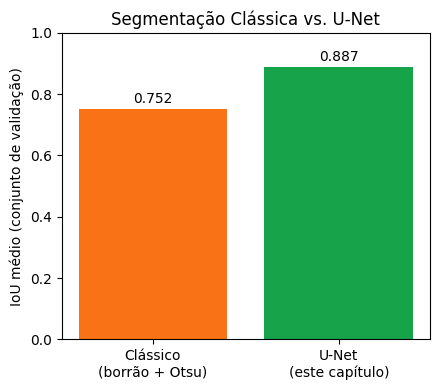

In [16]:
# @fig-09-unet-comparativo
metodos_seg = ["Clássico\n(borrão + Otsu)", "U-Net\n(este capítulo)"]
ious_medios = [iou_classico_medio, iou_unet_final]

plt.figure(figsize=(4.5, 4))
plt.bar(metodos_seg, ious_medios, color=["#f97316", "#16a34a"])
plt.ylim(0, 1.0)
plt.ylabel("IoU médio (conjunto de validação)")
plt.title("Segmentação Clássica vs. U-Net")
for i, v in enumerate(ious_medios):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

Além da comparação agregada, a inspeção lado a lado de exemplos individuais de validação evidencia onde, especificamente, a U-Net supera a linha de base clássica: nas bordas do nódulo, sobretudo nos casos em que o contraste local se aproxima do nível de ruído.

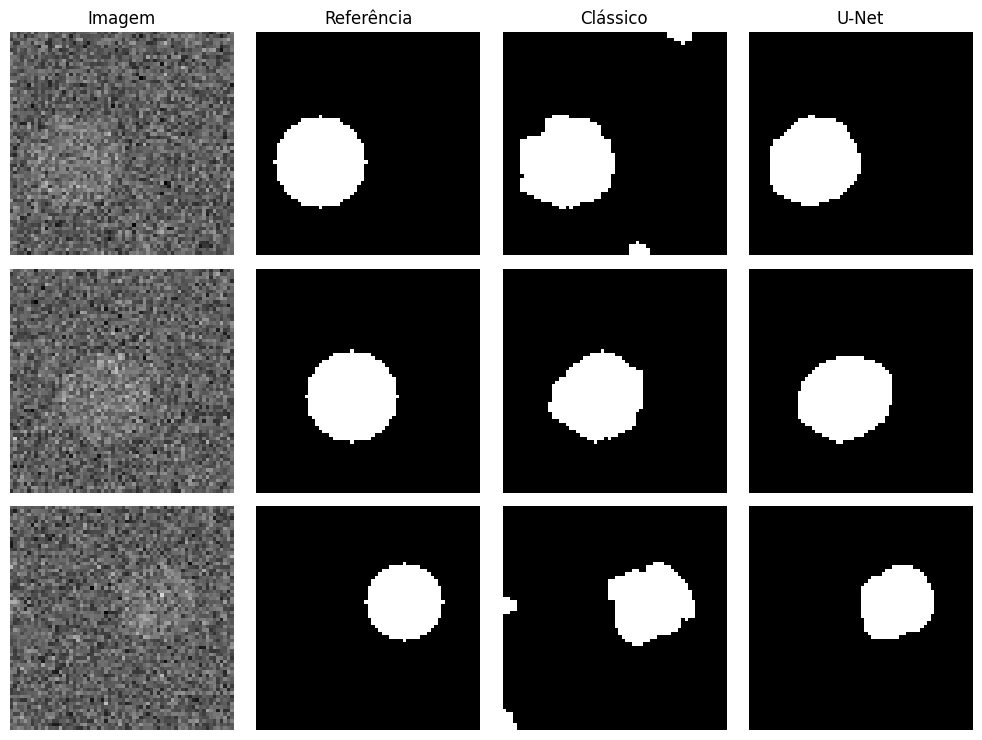

In [17]:
fig, axs = plt.subplots(3, 4, figsize=(10, 7.5))
for linha, i in enumerate([0, 1, 2]):
    with torch.no_grad():
        pred_unet = (torch.sigmoid(modelo_unet(X_val_unet[i:i+1])) > 0.5).float().squeeze().numpy() * 255
    pred_classico = segmenta_classico(imgs_val[i], elemento_estrutural)
    imagens_linha = [imgs_val[i], masks_val[i], pred_classico, pred_unet.astype(np.uint8)]
    titulos_linha = ["Imagem", "Referência", "Clássico", "U-Net"]
    for col in range(4):
        axs[linha, col].imshow(imagens_linha[col], cmap="gray", vmin=0, vmax=255)
        if linha == 0:
            axs[linha, col].set_title(titulos_linha[col])
        axs[linha, col].axis("off")
plt.tight_layout()
plt.show()

:::{.callout-note}
#### Por que funciona? — Conexões de atalho e os limites de uma regra fixa {.unnumbered}

A vantagem da U-Net sobre a linha de base clássica não decorre de operações fundamentalmente diferentes — ambas combinam convolução (fixa, no caso do borrão; aprendida, no caso da U-Net) com uma regra de decisão por pixel — mas de **onde** essa decisão final é tomada. A limiarização de Otsu aplica um único valor de corte, global, sobre uma estimativa de intensidade local; quando a diferença de média entre nódulo e fundo é pequena diante do ruído — como neste conjunto de dados, construído deliberadamente para isso — essa regra única erra sistematicamente nas bordas e em regiões em que o ruído local se aproxima do nódulo.

As conexões de atalho atacam exatamente esse problema. A base da rede, após três reduções de resolução, capta um contexto espacial amplo, suficiente para localizar aproximadamente a região do nódulo mesmo sob ruído — mas com resolução baixa demais para desenhar seu contorno com precisão. Reinjetar, em cada estágio do decodificador, o mapa de características de resolução equivalente do codificador devolve exatamente o detalhe espacial necessário para refinar essa localização aproximada em uma máscara pixel a pixel — algo que nenhuma regra de limiar único, por mais bem ajustada, consegue replicar quando o sinal está distribuído de forma sutil pela vizinhança de cada pixel, e não concentrado no valor de um único pixel isolado.
:::

### Aplicando a Mesma *Pipeline* a um Conjunto de Dados Real: Roboflow

Assim como a subseção de detecção com YOLO mostrou que um conjunto de dados sintético pode ser substituído por imagens reais sem alterar o código de treinamento, o mesmo princípio se aplica à U-Net: a única exigência é organizar as imagens e suas máscaras nos mesmos tensores `X` e `Y` construídos por `para_tensores`.

A **Roboflow** é uma plataforma de anotação, versionamento e exportação de conjuntos de dados de Visão Computacional, com um catálogo público (Roboflow Universe) que reúne conjuntos já anotados para classificação, detecção e segmentação, exportáveis em diversos formatos — entre eles, o formato de anotação YOLO já utilizado no Projeto Prático 2 e o formato `png-mask-semantic`, com uma máscara por imagem, diretamente compatível com a U-Net treinada nesta seção. Alternativas com propósito semelhante incluem o Kaggle Datasets e o Hugging Face Hub, mais orientados à descoberta de conjuntos de dados já publicados do que à anotação de imagens próprias; a escolha entre essas plataformas depende, sobretudo, de o conjunto de interesse já existir publicamente ou precisar ser anotado do zero.

O exemplo a seguir baixa um conjunto de dados real de segmentação a partir de um projeto hospedado na Roboflow e o adapta ao mesmo formato de tensores utilizado no treinamento da U-Net compacta, permitindo reaproveitar — sem qualquer alteração de arquitetura — as mesmas funções `perda_segmentacao`, `UNetCompacta` e o laço de treinamento já definidos.

:::{.callout-important}
As células a seguir **não são executadas automaticamente** neste notebook: requerem uma chave de API gratuita, obtida em `app.roboflow.com`, e o identificador (`workspace/projeto/versão`) de um conjunto de dados de segmentação específico, além de conexão à internet para o *download*. O código é apresentado como um gabarito completo, pronto para ser adaptado a qualquer conjunto de dados de segmentação hospedado na plataforma — consulte a documentação oficial (`docs.roboflow.com/developer/export-data`) para o formato exato de cada tipo de exportação.
:::

A adaptação é dividida em três partes: a instalação do pacote e o *download* do conjunto de dados; a leitura dos pares imagem/máscara exportados; e o reaproveitamento do laço de treinamento já definido.

In [ ]:
# eval: false
# 1. Instalação do pacote oficial da Roboflow
!pip install roboflow > /dev/null

# 2. Autenticação e download do conjunto de dados no formato de máscaras semânticas
from roboflow import Roboflow

rf = Roboflow(api_key="SUA_CHAVE_DE_API")  # chave gratuita, obtida em app.roboflow.com
projeto = rf.workspace("nome-do-workspace").project("nome-do-projeto")
dataset = projeto.version(1).download("png-mask-semantic")

# A exportação "png-mask-semantic" organiza o conjunto em pastas train/valid/test,
# cada uma com pares de arquivos <nome>.jpg e <nome>_mask.png

In [ ]:
# eval: false
import os
import glob

def carrega_split_roboflow(pasta, tam=TAM_IMG):
    # Lê os pares imagem/máscara de uma pasta exportada pela Roboflow e os
    # redimensiona para o mesmo tamanho utilizado no treinamento da U-Net.
    imagens, mascaras = [], []
    for caminho_mascara in sorted(glob.glob(f"{pasta}/*_mask.png")):
        caminho_imagem = caminho_mascara.replace("_mask.png", ".jpg")
        if not os.path.exists(caminho_imagem):
            continue
        img = cv2.resize(cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE), (tam, tam))
        mask = cv2.resize(cv2.imread(caminho_mascara, cv2.IMREAD_GRAYSCALE), (tam, tam))
        imagens.append(img)
        mascaras.append((mask > 127).astype(np.uint8) * 255)
    return imagens, mascaras

imgs_treino_real, masks_treino_real = carrega_split_roboflow(f"{dataset.location}/train")
imgs_val_real, masks_val_real = carrega_split_roboflow(f"{dataset.location}/valid")

X_treino_real, Y_treino_real = para_tensores(imgs_treino_real, masks_treino_real)
X_val_real, Y_val_real = para_tensores(imgs_val_real, masks_val_real)

In [ ]:
# eval: false
# Reaproveita a MESMA arquitetura, função de perda e laço de treinamento já
# definidos para o conjunto sintético -- apenas os tensores de entrada mudam.
modelo_unet_real = UNetCompacta()
otimizador_real = optim.Adam(modelo_unet_real.parameters(), lr=1e-3)

for epoca in range(epocas_unet):
    modelo_unet_real.train()
    perm = torch.randperm(X_treino_real.size(0))
    for i in range(0, X_treino_real.size(0), tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_real.zero_grad()
        perda = perda_segmentacao(modelo_unet_real(X_treino_real[idx]), Y_treino_real[idx])
        perda.backward()
        otimizador_real.step()

print("Treinamento da U-Net no conjunto de dados real concluído.")

Conjuntos de dados reais tipicamente excedem a resolução $64 \times 64$ usada no exemplo sintético desta seção. Ao adaptar a *pipeline* anterior a um novo conjunto de dados, recomenda-se aumentar `TAM_IMG` proporcionalmente à resolução das imagens originais e, se as estruturas de interesse forem pequenas em relação à imagem, ampliar também o parâmetro `base` da `UNetCompacta` ou acrescentar um quarto estágio de profundidade — o mesmo compromisso entre capacidade do modelo e custo computacional já discutido a propósito do número de camadas da CNN de classificação, agora aplicado ao contexto da segmentação.

## Integrando Geometria e Aprendizado Profundo

O capítulo se encerra retomando um fio condutor que atravessou toda a Parte II: a geometria projetiva (transformações de perspectiva e homografia, estudadas nos Capítulos 6 e 8) e o aprendizado profundo, apresentado ao longo deste capítulo, combinam-se para resolver problemas de Visão Computacional com aplicação direta no mundo real. Três aplicações ilustram essa integração.

### Realidade Aumentada

A realidade aumentada sobrepõe conteúdo virtual a uma cena real, alinhado geometricamente com ela. O princípio subjacente é exatamente o da homografia do Capítulo 8: detecta-se um marcador — ou, em sistemas modernos, características naturais da cena, aprendidas por uma rede — estima-se a transformação de perspectiva entre suas coordenadas conhecidas e sua posição na imagem, e essa mesma transformação é usada para deformar e posicionar um conteúdo virtual sobre a cena.

O exemplo utiliza um marcador **ArUco**: um padrão binário quadrado, de leitura robusta e não ambígua mesmo sob rotação e oclusão parcial, amplamente empregado como referência geométrica em aplicações de realidade aumentada e de calibração de câmera (Garrido-Jurado et al., 2014). A construção é dividida em três partes: a geração do marcador e sua inserção na cena por meio de uma homografia conhecida; a detecção do marcador na cena e a sobreposição de um conteúdo virtual por meio da homografia estimada; e a exibição comparativa.

In [18]:
dic = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco = cv2.cvtColor(cv2.aruco.generateImageMarker(dic, 7, 200), cv2.COLOR_GRAY2BGR)

src = np.float32([[0, 0], [200, 0], [200, 200], [0, 200]])
dst = np.float32([[150, 120], [430, 90], [460, 350], [140, 380]])

cena = np.full((480, 640, 3), 200, np.uint8)
H, _ = cv2.findHomography(src, dst)

mask = cv2.warpPerspective(np.full((200, 200), 255, np.uint8), H, (640, 480))
cena[mask > 0] = cv2.warpPerspective(aruco, H, (640, 480))[mask > 0]

Construída a cena com o marcador posicionado por homografia, procede-se à detecção automática do marcador e à estimativa da homografia entre suas coordenadas de referência e a posição detectada — homografia então reaproveitada para posicionar uma imagem virtual sobre o marcador.

In [19]:
det = cv2.aruco.ArucoDetector(dic, cv2.aruco.DetectorParameters())
corners, ids, _ = det.detectMarkers(cena)

virtual = cv2.resize(cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2BGR), (200, 200))
H, _ = cv2.findHomography(src, corners[0][0])

ra = cena.copy()
mask = cv2.warpPerspective(np.full((200, 200), 255, np.uint8), H, (640, 480))
ra[mask > 0] = cv2.warpPerspective(virtual, H, (640, 480))[mask > 0]

A @fig-09-realidade-aumentada exibe o marcador detectado na cena e o resultado da sobreposição do conteúdo virtual, alinhado à posição e à perspectiva do marcador.

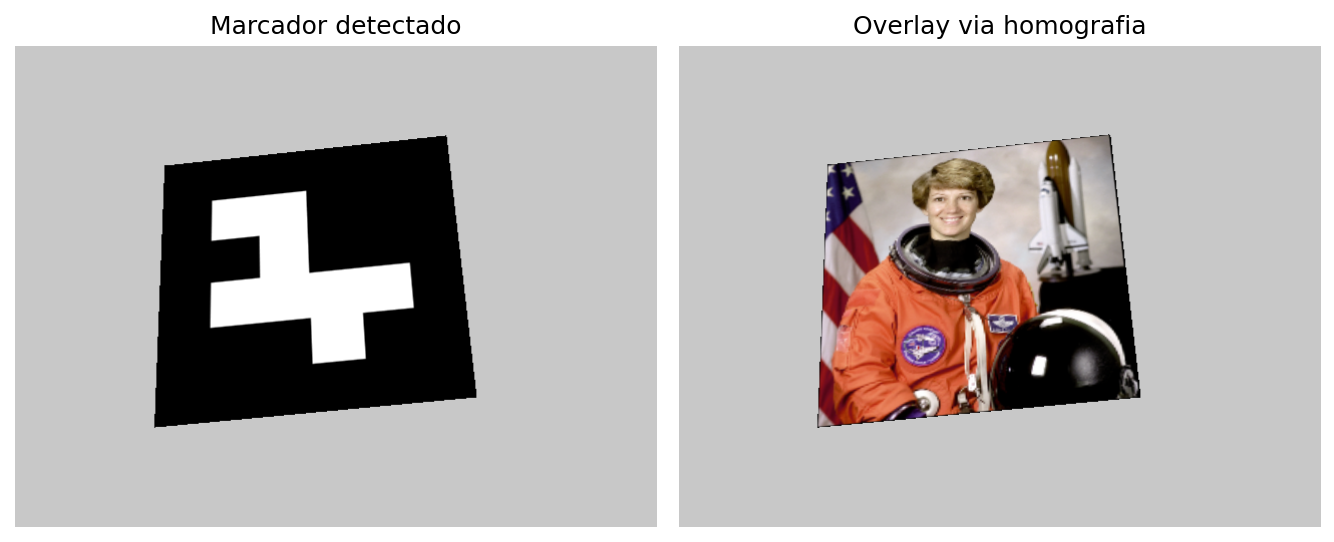

In [20]:
# @fig-09-realidade-aumentada
mm.show(
    [cv2.cvtColor(cena, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(ra, cv2.COLOR_BGR2RGB)],
    titles=["Marcador detectado", "Overlay via homografia"],
    cols=2, figsize=(9, 4)
)

> **Nota:** sistemas modernos de realidade aumentada, como o ARKit da Apple e o ARCore do Google, substituem marcadores explícitos por odometria visual-inercial (*visual-inertial odometry*) baseada em aprendizado profundo, capaz de rastrear características naturais da cena — sem a necessidade de um marcador impresso — e estimar a pose da câmera em tempo real, combinando imagens de câmera e leituras de acelerômetro e giroscópio (Mourikis & Roumeliotis, 2007). O princípio geométrico subjacente, porém, permanece o mesmo: alinhar conteúdo virtual à cena real por meio de uma transformação estimada.

### Fotogrametria e Referência de Escala

Uma pergunta recorrente em aplicações práticas é: dado um objeto medido apenas em pixels em uma fotografia, qual é seu tamanho real? A resposta clássica utiliza um objeto de referência de tamanho conhecido, presente na mesma imagem e à mesma distância aproximada da câmera. A construção do exemplo é dividida em quatro partes: a montagem da cena sintética; a detecção das caixas delimitadoras por segmentação de cor; o cálculo da razão de escala e das medidas; e a exibição do resultado.

In [21]:
COR_REFERENCIA = (200, 200, 200)  # cartão de referência: cinza claro
COR_OBJETO = (60, 60, 220)         # objeto a medir: vermelho

# Cena original: os objetos são desenhados PREENCHIDOS, como apareceriam de fato
# em uma foto -- e não apenas como contornos de caixa delimitadora.
cena_medicao = np.full((300, 500, 3), 255, dtype=np.uint8)
cv2.rectangle(cena_medicao, (30, 200), (30 + 140, 200 + 88), COR_REFERENCIA, -1)   # referência conhecida
cv2.rectangle(cena_medicao, (250, 100), (250 + 220, 100 + 150), COR_OBJETO, -1)    # objeto a medir

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

A função `caixa_delimitadora_por_cor` isola cada objeto por proximidade de cor e retorna sua caixa delimitadora em pixels — a mesma representação de retângulo alinhado aos eixos empregada na detecção com YOLO no Projeto Prático 2, aqui obtida por um método puramente clássico.

In [22]:
def caixa_delimitadora_por_cor(imagem_bgr, cor_bgr, tolerancia=40):
    diferenca = np.abs(imagem_bgr.astype(int) - np.array(cor_bgr)).sum(axis=2)
    mascara = (diferenca < tolerancia).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    maior_contorno = max(contornos, key=cv2.contourArea)
    return cv2.boundingRect(maior_contorno)  # (x, y, largura, altura) em pixels

x_ref, y_ref, w_ref_px, h_ref_px = caixa_delimitadora_por_cor(cena_medicao, COR_REFERENCIA)
x_obj, y_obj, w_obj_px, h_obj_px = caixa_delimitadora_por_cor(cena_medicao, COR_OBJETO)

Conhecida a largura real do objeto de referência — um cartão de 8,56 cm de largura, dimensão padronizada pela norma ISO/IEC 7810 —, a razão entre centímetros e pixels é obtida diretamente da largura do cartão detectada na imagem e, em seguida, aplicada à caixa delimitadora do objeto de interesse.

In [23]:
LARGURA_REFERENCIA_CM = 8.56  # largura padrão de um cartão (ISO/IEC 7810)
razao_cm_por_px = LARGURA_REFERENCIA_CM / w_ref_px
largura_obj_cm = w_obj_px * razao_cm_por_px
altura_obj_cm = h_obj_px * razao_cm_por_px

A @fig-09-fotogrametria apresenta a cena original e o painel de resultado, com as caixas delimitadoras detectadas e as medições estimadas sobrepostas.

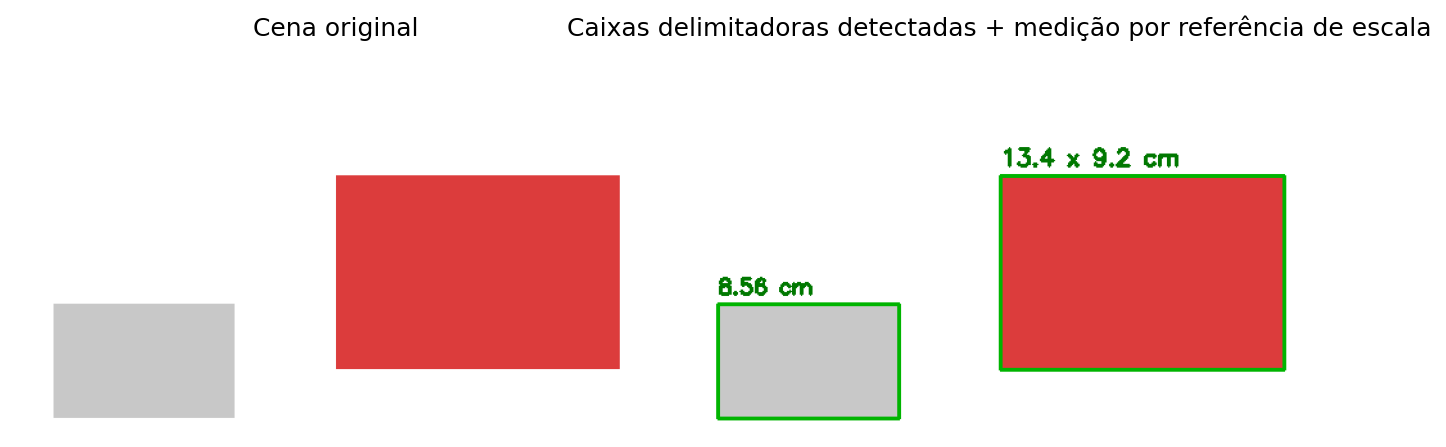

In [24]:
# @fig-09-fotogrametria
resultado = cena_medicao.copy()
cv2.rectangle(resultado, (x_ref, y_ref), (x_ref + w_ref_px, y_ref + h_ref_px), (0, 180, 0), 2)
cv2.rectangle(resultado, (x_obj, y_obj), (x_obj + w_obj_px, y_obj + h_obj_px), (0, 180, 0), 2)

cv2.putText(resultado, f"{LARGURA_REFERENCIA_CM:.2f} cm",
            (x_ref, y_ref - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 0), 2)
cv2.putText(resultado, f"{largura_obj_cm:.1f} x {altura_obj_cm:.1f} cm",
            (x_obj, y_obj - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 120, 0), 2)

mm.show(
    [cv2.cvtColor(cena_medicao, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)],
    titles=["Cena original", "Caixas delimitadoras detectadas + medição por referência de escala"],
    cols=2, figsize=(9, 4)
)

Essa é a base da fotogrametria clássica — a mesma lógica se estende, com maior sofisticação geométrica (calibração de câmera, correção de distorção de lente, múltiplas vistas), a aplicações como levantamento topográfico por drones e reconstrução tridimensional de objetos a partir de fotografias (Szeliski, 2010).

### Visão Estereoscópica

Enquanto a fotogrametria descrita acima assume uma única imagem e um objeto de referência conhecido, a visão estereoscópica estima profundidade diretamente a partir de duas câmeras — ou duas fotografias da mesma cena, tiradas de posições ligeiramente diferentes —, seguindo o mesmo princípio da visão binocular humana. A ideia central é a disparidade: um ponto próximo à câmera se desloca mais, entre as duas imagens, do que um ponto distante.

Formalmente, a profundidade $Z$ de um ponto se relaciona à disparidade $d$ (a diferença de posição horizontal do mesmo ponto nas duas imagens) por:

$$
Z = \frac{f \cdot B}{d},
$$

em que $f$ é a distância focal da câmera e $B$ é a linha de base (*baseline*) — a distância entre os dois pontos de captura (Szeliski, 2010). Quanto maior a disparidade, menor a profundidade correspondente, isto é, mais próximo o objeto está da câmera.

A construção do exemplo sintético é dividida em três partes: a criação de um par estéreo a partir de deslocamentos horizontais distintos para fundo e objeto; o cálculo do mapa de disparidade; e a exibição comparativa.

In [25]:
img_base = cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2GRAY)

DESLOC_FUNDO = 4    # pequeno deslocamento: objeto distante
DESLOC_OBJETO = 22  # grande deslocamento: objeto próximo à câmera

def deslocar(imagem, dx):
    M_desloc = np.float32([[1, 0, dx], [0, 1, 0]])
    return cv2.warpAffine(imagem, M_desloc, (imagem.shape[1], imagem.shape[0]))

img_esquerda = img_base.copy()
img_direita = deslocar(img_base, -DESLOC_FUNDO)

# Simula um objeto em primeiro plano com deslocamento (disparidade) maior
y0, y1, x0, x1 = 180, 340, 200, 360
img_direita[y0:y1, x0:x1] = deslocar(img_base, -DESLOC_OBJETO)[y0:y1, x0:x1]

Construído o par estéreo, o algoritmo clássico de correspondência por blocos (*Block Matching*), implementado em `cv2.StereoBM_create`, varre cada bloco da imagem esquerda em busca de sua correspondência na imagem direita, produzindo o mapa de disparidade correspondente.

In [26]:
correspondencia_estereo = cv2.StereoBM_create(numDisparities=32, blockSize=15)
mapa_disparidade = correspondencia_estereo.compute(img_esquerda, img_direita).astype(np.float32) / 16.0

disp_fundo = mapa_disparidade[:150, :150].mean()
disp_objeto = mapa_disparidade[200:320, 220:340].mean()
print(f"Disparidade média no fundo: {disp_fundo:.2f} px")
print(f"Disparidade média no objeto em primeiro plano: {disp_objeto:.2f} px")
print("Disparidade maior corresponde a objeto mais próximo da câmera, conforme a equação Z = f.B/d.")

Disparidade média no fundo: 2.58 px
Disparidade média no objeto em primeiro plano: 21.63 px
Disparidade maior corresponde a objeto mais próximo da câmera, conforme a equação Z = f.B/d.


A @fig-09-visao-estereo exibe o par estéreo sintético e o mapa de disparidade correspondente, em que regiões mais claras indicam maior disparidade e, portanto, maior proximidade em relação à câmera.

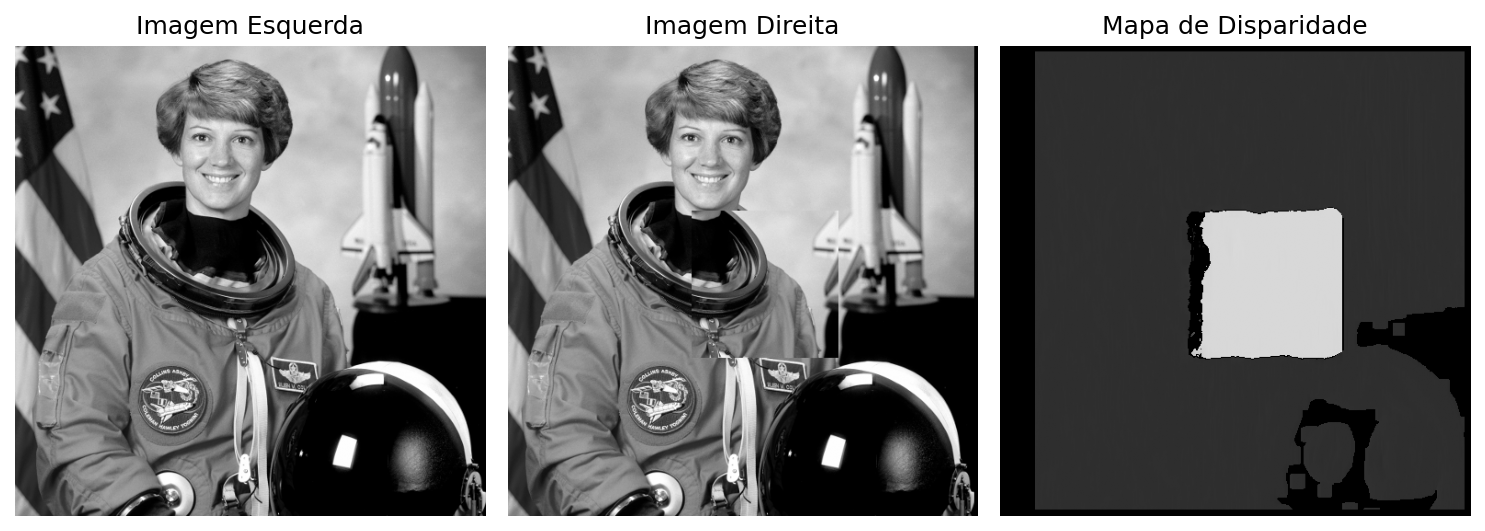

In [27]:
# @fig-09-visao-estereo
mm.show(
    [img_esquerda, img_direita, mapa_disparidade],
    titles=["Imagem Esquerda", "Imagem Direita", "Mapa de Disparidade"],
    cols=3, figsize=(10, 3.5)
)

> **Nota:** métodos clássicos de correspondência estéreo, como o utilizado acima, comparam diretamente blocos de pixels entre as duas imagens — uma tarefa que sofre em regiões de textura pouco distintiva, como paredes lisas ou céu uniforme. Redes neurais de estimativa de profundidade monocular (a partir de uma única imagem) (Eigen, Puhrsch & Fergus, 2014) e de correspondência estéreo aprendida superam essa limitação ao aprender priors visuais sobre a estrutura de cenas do mundo real a partir de grandes volumes de dados — um caso de uso direto das redes convolucionais estudadas neste capítulo, aplicado diretamente ao problema geométrico com o qual o capítulo se encerra.

### Referências

- EIGEN, D.; PUHRSCH, C.; FERGUS, R. **Depth Map Prediction from a Single Image Using a Multi-Scale Deep Network**. In: Advances in Neural Information Processing Systems (NeurIPS), 2014.
- EVERINGHAM, M.; VAN GOOL, L.; WILLIAMS, C. K. I.; WINN, J.; ZISSERMAN, A. **The Pascal Visual Object Classes (VOC) Challenge**. International Journal of Computer Vision, v. 88, n. 2, p. 303–338, 2010.
- GARRIDO-JURADO, S.; MUÑOZ-SALINAS, R.; MADRID-CUEVAS, F. J.; MARÍN-JIMÉNEZ, M. J. **Automatic Generation and Detection of Highly Reliable Fiducial Markers under Occlusion**. Pattern Recognition, v. 47, n. 6, p. 2280–2292, 2014.
- KINGMA, D. P.; BA, J. **Adam: A Method for Stochastic Optimization**. In: International Conference on Learning Representations (ICLR), 2015.
- MILLETARI, F.; NAVAB, N.; AHMADI, S.-A. **V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation**. In: International Conference on 3D Vision (3DV), 2016.
- MOURIKIS, A. I.; ROUMELIOTIS, S. I. **A Multi-State Constraint Kalman Filter for Vision-Aided Inertial Navigation**. In: IEEE International Conference on Robotics and Automation (ICRA), 2007.
- OTSU, N. **A Threshold Selection Method from Gray-Level Histograms**. IEEE Transactions on Systems, Man, and Cybernetics, v. 9, n. 1, p. 62–66, 1979.
- RONNEBERGER, O.; FISCHER, P.; BROX, T. **U-Net: Convolutional Networks for Biomedical Image Segmentation**. In: Medical Image Computing and Computer-Assisted Intervention (MICCAI), 2015.
- SZELISKI, R. **Computer Vision: Algorithms and Applications**. London: Springer, 2010.